c:\Users\Shaik Rashed Shariff\anaconda3\envs\newenv\Lib\site-packages\xgboost\training.py:199: UserWarning: [08:43:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



⚡ XGBoost Accuracy: 0.9878777205418336

📊 Classification Report:

              precision    recall  f1-score   support

    Backdoor       0.99      0.98      0.98     19099
         DoS       0.99      1.00      0.99     10849
     Generic       1.00      1.00      1.00     11462
       Probe       0.97      0.99      0.98     14558
        Worm       0.99      0.99      0.99     12171

    accuracy                           0.99     68139
   macro avg       0.99      0.99      0.99     68139
weighted avg       0.99      0.99      0.99     68139



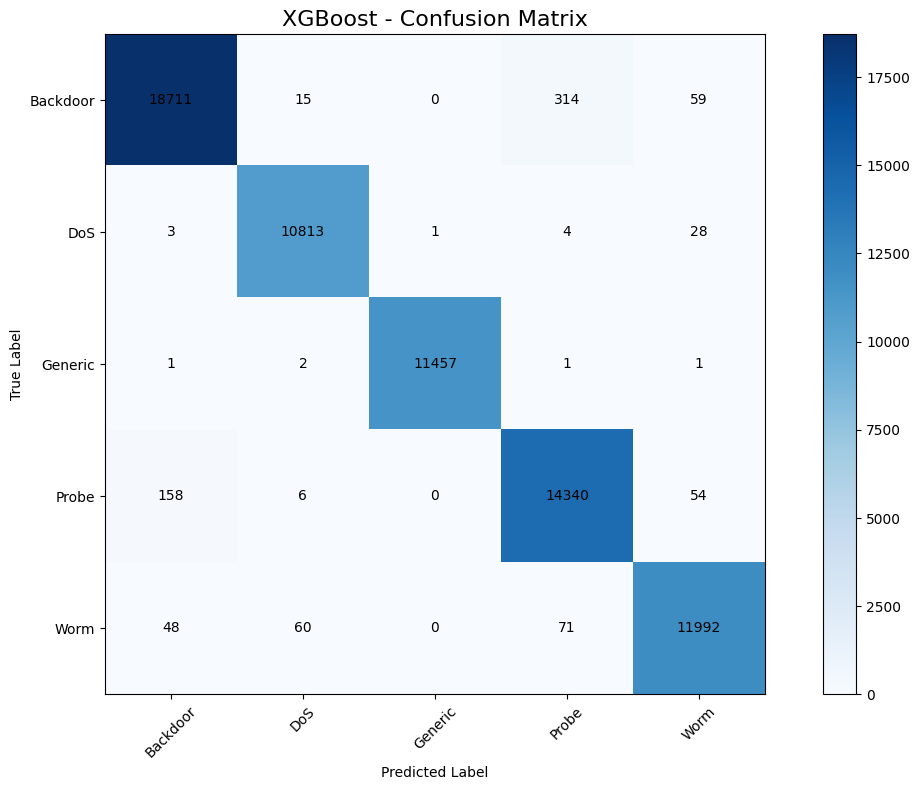


✅ Model, Scaler, Encoder saved successfully!


In [5]:
# ==============================
# ⚡ XGBoost IDS Model
# ==============================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

# ==============================
# 📥 Load Dataset
# ==============================

df = pd.read_csv("UNSW-NB15_Dataset.csv")
df = df.dropna()

X = df.drop("attack", axis=1)
y = df["attack"]

# ==============================
# 🔤 Encoding + Scaling
# ==============================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# ✂️ Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ==============================
# ⚡ Train XGBoost
# ==============================

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
# 📊 Predictions
# ==============================

y_pred = model.predict(X_test)

# ==============================
# 📈 Evaluation
# ==============================

print("\n⚡ XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# ==============================
# 🔥 Confusion Matrix (Beautiful)
# ==============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))
plt.imshow(cm, cmap="Blues")

plt.title("XGBoost - Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

classes = label_encoder.classes_

plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes)

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="black"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

# ==============================
# 💾 Save Model
# ==============================

# ==============================

joblib.dump(model, "lightgbm_ids_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("\n✅ Model, Scaler, Encoder saved successfully!")


🌲 Random Forest Accuracy: 0.9825503749688137

📊 Classification Report:

              precision    recall  f1-score   support

    Backdoor       0.98      0.97      0.98     19099
         DoS       0.99      1.00      0.99     10849
     Generic       1.00      1.00      1.00     11462
       Probe       0.96      0.98      0.97     14558
        Worm       0.99      0.98      0.99     12171

    accuracy                           0.98     68139
   macro avg       0.98      0.98      0.98     68139
weighted avg       0.98      0.98      0.98     68139



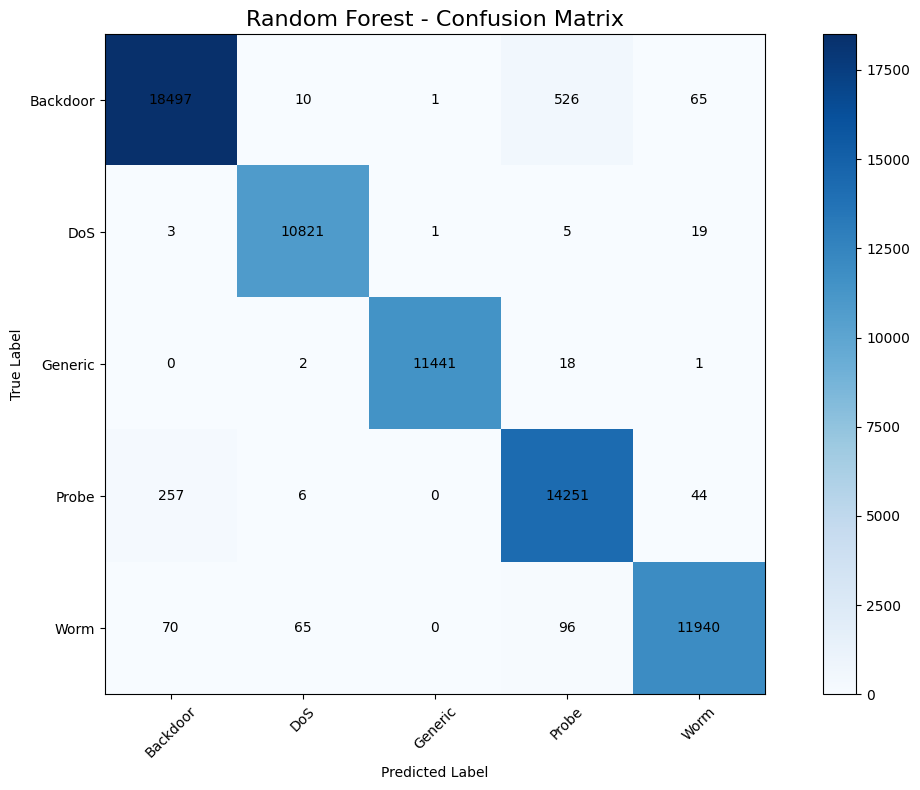

['rf_label_encoder.pkl']

In [6]:
# ==============================
# 🌲 Random Forest IDS Model
# ==============================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

# ==============================
# 📥 Load Dataset
# ==============================

df = pd.read_csv("UNSW-NB15_Dataset.csv")
df = df.dropna()

X = df.drop("attack", axis=1)
y = df["attack"]

# ==============================
# 🔤 Encoding + Scaling
# ==============================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# ✂️ Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ==============================
# 🌲 Train Random Forest
# ==============================

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ==============================
# 📊 Predictions
# ==============================

y_pred = model.predict(X_test)

# ==============================
# 📈 Evaluation
# ==============================

print("\n🌲 Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# ==============================
# 🔥 Confusion Matrix (Beautiful)
# ==============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))
plt.imshow(cm, cmap="Blues")

plt.title("Random Forest - Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

classes = label_encoder.classes_

plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes)

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="black"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

# ==============================
# 💾 Save Model
# ==============================

joblib.dump(model, "rf_model.pkl")
joblib.dump(scaler, "rf_scaler.pkl")
joblib.dump(label_encoder, "rf_label_encoder.pkl")



In [7]:
# ==============================
# 🚀 Load Model & Predict
# ==============================

import pandas as pd
import numpy as np
import joblib

# Load saved components
model = joblib.load("lightgbm_ids_model.pkl")
scaler = joblib.load("scaler.pkl")
label_encoder = joblib.load("label_encoder.pkl")

# Load dataset (same structure as training)
df = pd.read_csv("UNSW-NB15_Dataset.csv")

# Preprocess same as training
df = df.dropna()

X = df.drop("attack", axis=1)

# Take first 50 rows
X_sample = X.iloc[:50]

# Scale
X_scaled = scaler.transform(X_sample)

# Predict
y_pred = model.predict(X_scaled)

# Decode labels
predicted_labels = label_encoder.inverse_transform(y_pred)

# ==============================
# 🧠 Suggestion Function (LLM-ready)
# ==============================

def generate_suggestion(attack):
    suggestions = {
        "DoS": "Limit traffic rate, enable firewall rules, and monitor abnormal spikes.",
        "Worm": "Isolate infected systems and update antivirus signatures.",
        "Backdoor": "Scan system for unauthorized access and remove malicious entries.",
        "Generic": "Analyze traffic patterns and block suspicious IP addresses.",
        "Normal": "No action required. System is operating normally."
    }
    return suggestions.get(attack, "Investigate unusual behavior and monitor logs.")

# ==============================
# 📊 Print Results
# ==============================

for i in range(50):
    print(f"\n🔍 Record {i+1}")
    print("Prediction:", predicted_labels[i])
    print("💡 Suggestion:", generate_suggestion(predicted_labels[i]))


🔍 Record 1
Prediction: Worm
💡 Suggestion: Isolate infected systems and update antivirus signatures.

🔍 Record 2
Prediction: Worm
💡 Suggestion: Isolate infected systems and update antivirus signatures.

🔍 Record 3
Prediction: Worm
💡 Suggestion: Isolate infected systems and update antivirus signatures.

🔍 Record 4
Prediction: Worm
💡 Suggestion: Isolate infected systems and update antivirus signatures.

🔍 Record 5
Prediction: Backdoor
💡 Suggestion: Scan system for unauthorized access and remove malicious entries.

🔍 Record 6
Prediction: Backdoor
💡 Suggestion: Scan system for unauthorized access and remove malicious entries.

🔍 Record 7
Prediction: Backdoor
💡 Suggestion: Scan system for unauthorized access and remove malicious entries.

🔍 Record 8
Prediction: Backdoor
💡 Suggestion: Scan system for unauthorized access and remove malicious entries.

🔍 Record 9
Prediction: Backdoor
💡 Suggestion: Scan system for unauthorized access and remove malicious entries.

🔍 Record 10
Prediction: Backdo